# XGBoost training and testing

### 1. Introduction


In this notebook, we are going to test and try an XGBoost model.

### 2. Librairies


In [62]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

### 3. Load Data, Filter and Pivot to Wide

In [63]:
# 1 : Load
df_long = pd.read_csv('../Data/dataREanonymized_long.csv')

# 2 : Finding the subjects with non-null discharge_mrs values
valid_subjects = df_long[
    (df_long['variable'] == 'discharge_mrs') &
    (df_long['Value'].notna())
]['subject_id'].unique()

# 3 : Filter the DataFrame to only include valid subjects
df_long_filtered = df_long[df_long['subject_id'].isin(valid_subjects)]

# 4 : Pivot to Wide format
df_wide = df_long_filtered.pivot(index='subject_id', columns='variable', values='Value').reset_index()

# 5 : Keep only rows where stroke_type is "ischemic"
df_wide = df_wide[df_wide['stroke_type'] == 'ischemic']
df_wide = df_wide[df_wide['thrombolysis'] == '1']


C:\Users\2432741\AppData\Local\Temp\ipykernel_2936\890118506.py:2: DtypeWarning: Columns (0: Value) have mixed types. Specify dtype option on import or set low_memory=False.
  df_long = pd.read_csv('../Data/dataREanonymized_long.csv')


### 4. Target variable extraction & Features

In [64]:
# 1. Extraction of the target variable (y)
target_raw = pd.to_numeric(df_wide['three_m_mrs'], errors='coerce')
y = (target_raw <= 2).astype(int)

# 2. Isolation of the features (X)
X = df_wide.drop(columns=['three_m_mrs', 'stroke_type', 'door_to_groin', 'thrombolysis', 'subject_id',
                          'bleeding_source', 'bleeding_volume_value', 'department_type', 'dysphagia_screening_type',
                          'gender', 'hospitalized_in', 'imaging_type', 'no_thrombolysis_reason',
                          'stroke_mimics_diagnosis'])

# 3. Numerical conversion of the features to ensure they are all numeric
X = X.apply(pd.to_numeric, errors='coerce')

# 4. Delete columns that are entirely NaN to prevent KNN Imputer from silently dropping them later
X = X.dropna(how='all', axis=1)

X.head(70
       )

variable,age,before_onset_antidiabetics,before_onset_cilostazol,before_onset_clopidrogel,before_onset_dipyridamol,before_onset_prasugrel,before_onset_ticagrelor,before_onset_ticlopidine,before_onset_warfarin,cholesterol,covid_test,dis_blood_pressure,discharge_antidiabetics,discharge_apixaban,discharge_cilostazol,discharge_clopidrogel,discharge_dabigatran,discharge_dipyridamol,discharge_edoxaban,discharge_heparin,discharge_mrs,discharge_nihss_score,discharge_prasugrel,discharge_rivaroxaban,discharge_ticagrelor,discharge_ticlopidine,discharge_warfarin,door_to_imaging,door_to_needle,glucose,hospital_stroke,hypoperfusion_core,imaging_done,nihss_score,occup_physiotherapy_received,onset_to_door,perfusion_core,physiotherapy_start_within_3days,prenotification,prestroke_mrs,risk_congestive_heart_failure,risk_coronary_artery_disease_or_myocardial_infarction,risk_diabetes,risk_hiv,risk_hyperlipidemia,risk_hypertension,risk_previous_hemorrhagic_stroke,risk_previous_ischemic_stroke,risk_smoker,sys_blood_pressure,tici_score
4,59,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,115.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,7.0,15.0,6.5,0.0,NaN,1.0,15.0,NaN,70.0,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN,1.0,0.0,NaN,NaN,0.0,180.0,NaN
16,81,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.65,NaN,100.0,NaN,0.0,0.0,1.0,0.0,NaN,0.0,0.0,4.0,6.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0,5.1,0.0,47.0,1.0,11.0,1.0,100.0,0.0,NaN,NaN,0.0,0.0,NaN,1.0,NaN,0.0,1.0,NaN,NaN,0.0,165.0,NaN
22,70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.37,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,8.0,6.8,0.0,206.0,1.0,5.0,0.0,-1365.0,97.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,180.0,NaN
25,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,1.0,6.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,141.0,NaN,0.0,NaN,1.0,16.0,NaN,99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1.0,NaN,0.0,0.0,1.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,58.0,NaN,0.0,NaN,1.0,15.0,NaN,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,69,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.64,0.0,100.0,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,15.0,12.0,5.8,0.0,NaN,1.0,4.0,0.0,75.0,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN,0.0,0.0,NaN,NaN,1.0,160.0,NaN
359,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,0.0,6.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,44.0,NaN,0.0,NaN,1.0,22.0,NaN,161.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,73,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.77,0.0,120.0,NaN,0.0,0.0,1.0,0.0,NaN,0.0,1.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,6.7,0.0,94.0,1.0,7.0,1.0,79.0,6.0,NaN,NaN,0.0,0.0,NaN,0.0,NaN,1.0,1.0,NaN,NaN,0.0,199.0,NaN
368,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,23.0,NaN,0.0,NaN,1.0,6.0,NaN,137.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
## Debug
# Crée un fichier "mes_features.txt" dans ton dossier
with open("mes_features.txt", "w") as f:
    for col in X.columns:
        f.write(f"{col}\n")

print("Fichier 'mes_features.txt' créé.")

Fichier 'mes_features.txt' créé.


### 5. Categorizing

In [67]:
# ==========================================
# Creation of a new feature: anticoagulants_discharge
# ==========================================

anticoagulants_during_discharge =  ['discharge_apixaban', 'discharge_dabigatran', 'discharge_edoxaban', 'discharge_rivaroxaban', 'discharge_warfarin', 'discharge_heparin']

df_wide['anticoagulant_discharge'] = df_wide[anticoagulants_during_discharge].max(axis=1)

df_wide = df_wide.drop(columns=anticoagulants_during_discharge)

In [68]:
# ==========================================
# Creation of a new feature: anticoagulants_before_onset
# ==========================================

anticoagulants_before_onset =  ['before_onset_warfarin']

df_wide['anticoagulant_before_onset'] = df_wide[anticoagulants_before_onset].max(axis=1)

df_wide = df_wide.drop(columns=anticoagulants_before_onset)

In [69]:
# ==========================================
# NIHSS : Three categories: (1) NIHSS<6, (2) 6≤NIHSS<16, (3) NIHSS≥16
# ==========================================

df_wide['nihss_score'] = pd.to_numeric(df_wide['nihss_score'], errors='coerce')

limits = [-np.inf, 6, 16, np.inf]
label = [0, 1, 2]

df_wide['nihss_score'] = pd.cut( df_wide['nihss_score'], bins=limits, labels=label, right=False)

df_wide['nihss_score'] = pd.to_numeric(df_wide['nihss_score'],)

In [70]:
# ==========================================
# Systolic Blood Pressure (SBP, mmHg) 
# Patients treated with IVT and/or EVT
# Three categories: (1) SBP≤110, (2) 110<SBP<180, (3) SBP≥180
# ==========================================

df_wide['sys_blood_pressure'] = pd.to_numeric(df_wide['sys_blood_pressure'], errors='coerce')

limits = [-np.inf, 111, 180, np.inf]
label = [0, 1, 2]

df_wide['sys_blood_pressure'] = pd.cut( df_wide['sys_blood_pressure'], bins=limits, labels=label, right=False)

df_wide['sys_blood_pressure'] = pd.to_numeric(df_wide['sys_blood_pressure'])

In [71]:
# ==========================================
# Diastolic Blood Pressure (DBP, mmHg) 
# Patients treated with IVT and/or EVT
# Two categories: (1) DBP<105, (2) DBP≥105
# ==========================================

df_wide['dis_blood_pressure'] = pd.to_numeric(df_wide['dis_blood_pressure'], errors='coerce')

limits = [-np.inf, 105, np.inf]
label = [0, 1]

df_wide['dis_blood_pressure'] = pd.cut( df_wide['dis_blood_pressure'], bins=limits, labels=label, right=False)

df_wide['dis_blood_pressure'] = pd.to_numeric(df_wide['dis_blood_pressure'])

In [72]:
# ==========================================
# Blood glucose (mg/dl)
# Three categories: (1) glucose<60, (2) 60≤glucose≤140, (3) glucose>140 
# ==========================================

df_wide['glucose'] = pd.to_numeric(df_wide['glucose'], errors='coerce')

limits = [-np.inf, 60, 141, np.inf]
label = [0, 1, 2]

df_wide['glucose'] = pd.cut( df_wide['glucose'], bins=limits, labels=label, right=False)

df_wide['glucose'] = pd.to_numeric(df_wide['glucose'])

In [73]:
# ==========================================
# Cholesterol (LDL-C, mg/dl)
# Three categories: (1) LDL-C<70, (2) 70≤LDL-C≤100, (3) LDL-C>100
# ==========================================

df_wide['cholesterol'] = pd.to_numeric(df_wide['cholesterol'], errors='coerce')

limits = [-np.inf, 70, 101, np.inf]
label = [0, 1, 2]

df_wide['cholesterol'] = pd.cut( df_wide['cholesterol'], bins=limits, labels=label, right=False)

df_wide['cholesterol'] = pd.to_numeric(df_wide['cholesterol'])

In [74]:
# ==========================================
# Prestroke mRS
# Three categories: (1) 0≤mRS<2, (2) mRS=2, (3) 2<mRS≤5 
# ==========================================

df_wide['prestroke_mrs'] = pd.to_numeric(df_wide['prestroke_mrs'], errors='coerce')

limits = [-np.inf, 2, 3, np.inf]
label = [0, 1, 2]

df_wide['prestroke_mrs'] = pd.cut( df_wide['prestroke_mrs'], bins=limits, labels=label, right=False)

df_wide['prestroke_mrs'] = pd.to_numeric(df_wide['prestroke_mrs'])

In [75]:
# ==========================================
# Onset to door (OTD, hours)
# Patients treated with only IVT
# Three categories: (1) OTD≤4.5, (2) 4.5<OTD≤24, (3) OTD>24  
# ==========================================

df_wide['onset_to_door'] = pd.to_numeric(df_wide['onset_to_door'], errors='coerce')

limits = [-np.inf, 4.5, 24, np.inf]
label = [0, 1, 2]

df_wide['onset_to_door'] = pd.cut( df_wide['onset_to_door'], bins=limits, labels=label, right=True)

df_wide['onset_to_door'] = pd.to_numeric(df_wide['onset_to_door'])

In [76]:
# ==========================================
# Door to imaging (DTI, minutes)
# Two categories: (1) DTI≤20, (2) DTI>20
# ==========================================

df_wide['door_to_imaging'] = pd.to_numeric(df_wide['door_to_imaging'], errors='coerce')

limits = [-np.inf, 20, np.inf]
label = [0, 1]

df_wide['door_to_imaging'] = pd.cut( df_wide['door_to_imaging'], bins=limits, labels=label, right=True)

df_wide['door_to_imaging'] = pd.to_numeric(df_wide['door_to_imaging'])

In [77]:
# ==========================================
# Door to needle (DTN, minutes)
# Four categories: (1) DTN≤30, (2) 30<DTN≤45, (3) 45<DTN≤60, (4) DTN>60
# ==========================================

df_wide['door_to_needle'] = pd.to_numeric(df_wide['door_to_needle'], errors='coerce')

limits = [-np.inf, 30, 45, 60, np.inf]
label = [0, 1, 2, 3]

df_wide['door_to_needle'] = pd.cut( df_wide['door_to_needle'], bins=limits, labels=label, right=True)

df_wide['door_to_needle'] = pd.to_numeric(df_wide['door_to_needle'])

### 5. Split of the Data

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 6. Imputing the Data

In [79]:
knn_imputer = KNNImputer(n_neighbors=5)

X_train_clean = pd.DataFrame(knn_imputer.fit_transform(X_train), columns=X_train.columns)
X_test_clean = pd.DataFrame(knn_imputer.transform(X_test), columns=X_test.columns)

### 7. Class balancing

In [80]:
count_zeros = (y_train == 0).sum()
count_ones = (y_train == 1).sum()
ratio_poids = count_zeros / count_ones

### 8. Hyperparameter grid & Random Search

In [81]:
xgboost_grid = {
    'n_estimators': [100, 300, 500],       
    'learning_rate': [0.01, 0.05, 0.1],     
    'max_depth': [3, 5, 7],                 
    'subsample': [0.7, 0.9, 1.0],           
    'colsample_bytree': [0.7, 0.9, 1.0]     
}

model_xgb = XGBClassifier(
    scale_pos_weight=ratio_poids, 
    eval_metric='logloss', 
    random_state=42,
    n_jobs=-1
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=model_xgb, 
    param_distributions=xgboost_grid, 
    n_iter=10,                 
    cv=cv_strategy,            
    random_state=42, 
    n_jobs=-1                  
)

In [82]:
random_search.fit(X_train_clean, y_train)

best_model = random_search.best_estimator_
print("The best parameters are :", random_search.best_params_)

The best parameters are : {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


### 9. Accuracy

In [83]:
test_score = best_model.score(X_test_clean, y_test)
print(f"\nScore d'exactitude (Accuracy) final sur le Test Set : {test_score * 100:.2f}%")


Score d'exactitude (Accuracy) final sur le Test Set : 85.71%


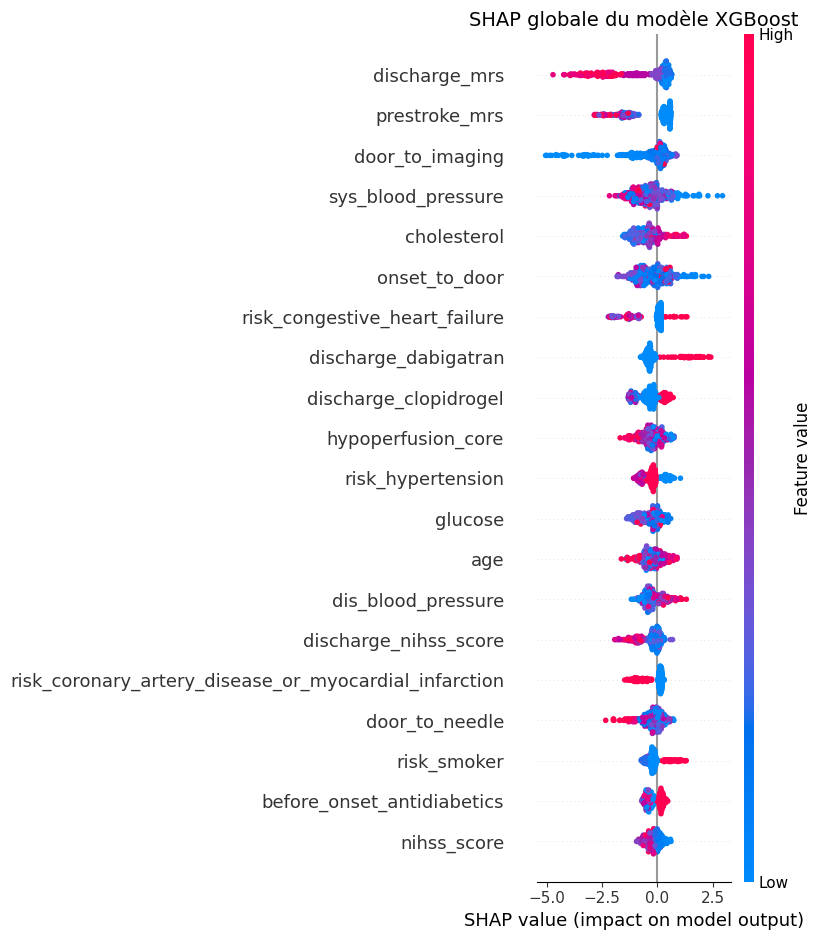

In [84]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer(X_test_clean)

plt.figure()
plt.title("SHAP globale du modèle XGBoost", fontsize=14)

shap.summary_plot(shap_values, X_test_clean, show=False)

plt.show()

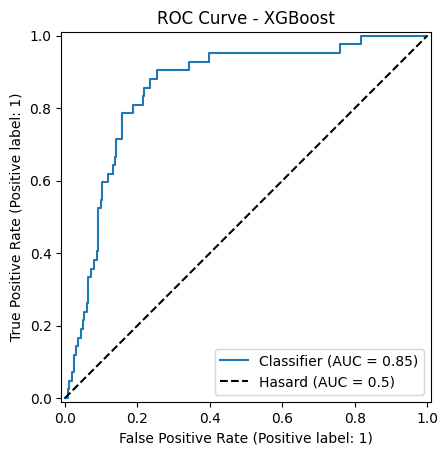

In [85]:
# y_pred = best_model.predict(X_test_clean)
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
# plt.title("Confusion Matrix - XGBoost")
# plt.show()

y_probs = best_model.predict_proba(X_test_clean)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_probs,)
plt.plot([0, 1], [0, 1], "k--", label="Hasard (AUC = 0.5)")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()